# **HOUSING PRICE PREDICTION**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing_Price_Prediction_DataSet.csv to Housing_Price_Prediction_DataSet.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
)



In [ ]:
df = pd.read_csv('Housing_Price_Prediction_DataSet.csv')

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.tail(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [ ]:
df.shape

(20640, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


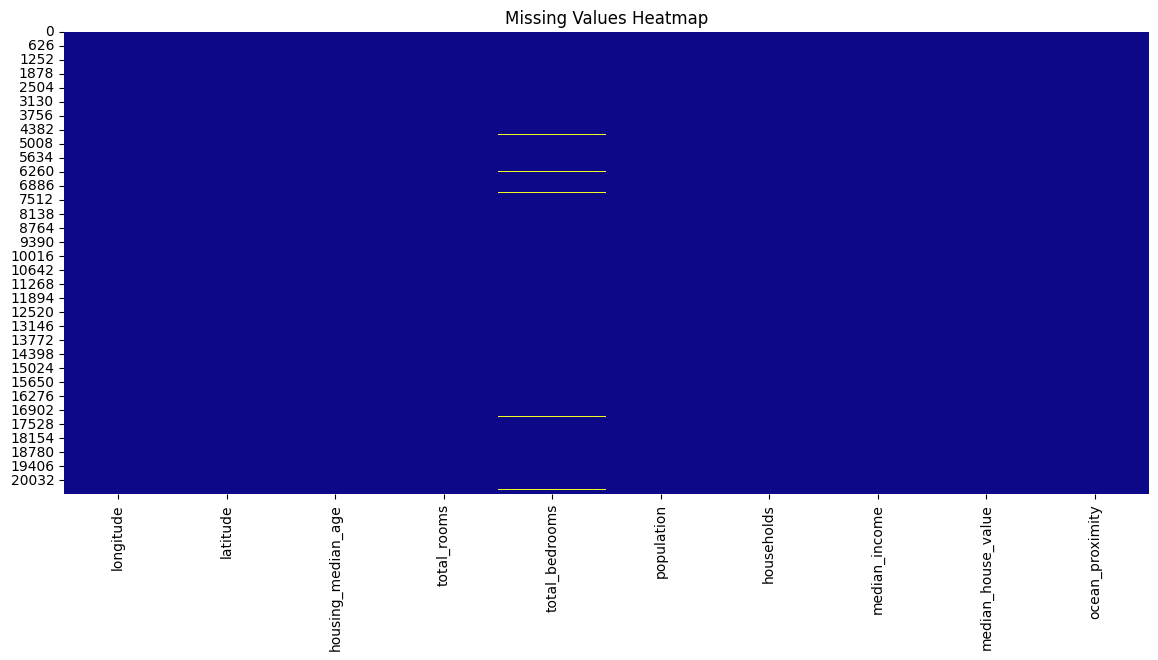

In [ ]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='plasma')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

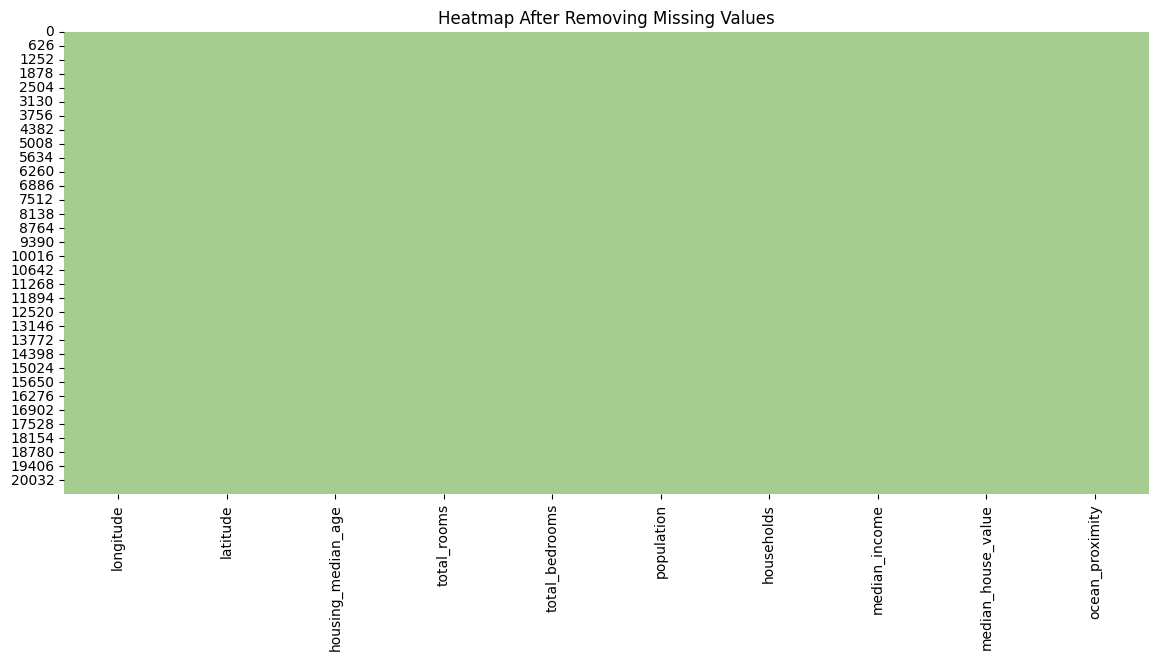

In [ ]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='crest')
plt.title("Heatmap After Removing Missing Values")
plt.show()

In [ ]:
dff =df['median_house_value'].value_counts()
print(dff)

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
352500.0      1
465000.0      1
457500.0      1
261200.0      1
307900.0      1
Name: count, Length: 3842, dtype: int64


In [ ]:
df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

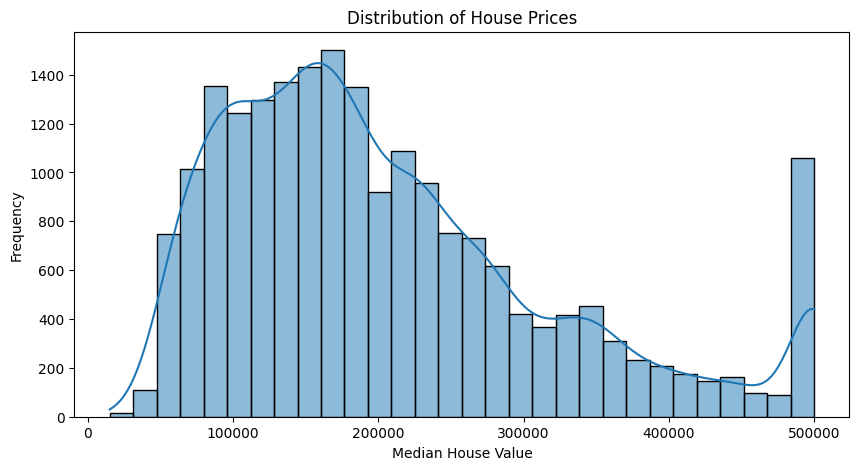

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['median_house_value'], bins=30, kde=True)

plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.show()

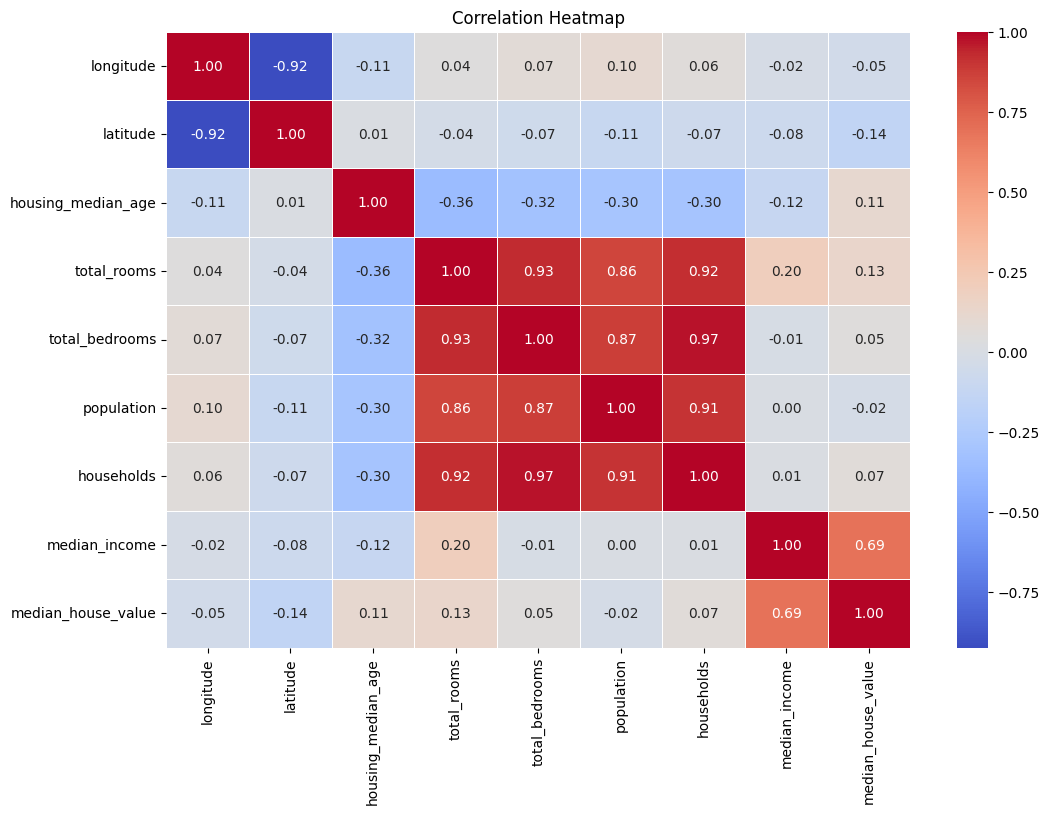

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['ocean_proximity'], dtype='object')


In [ ]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [ ]:
'ocean_proximity' in df.columns

True

In [ ]:
len(df.select_dtypes(include=['object']).columns)

1

Feature Selection

In [ ]:
corr_matrix = df.corr(numeric_only=True)

corr_with_target = corr_matrix['median_house_value'].sort_values(ascending=False)
print(corr_with_target)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


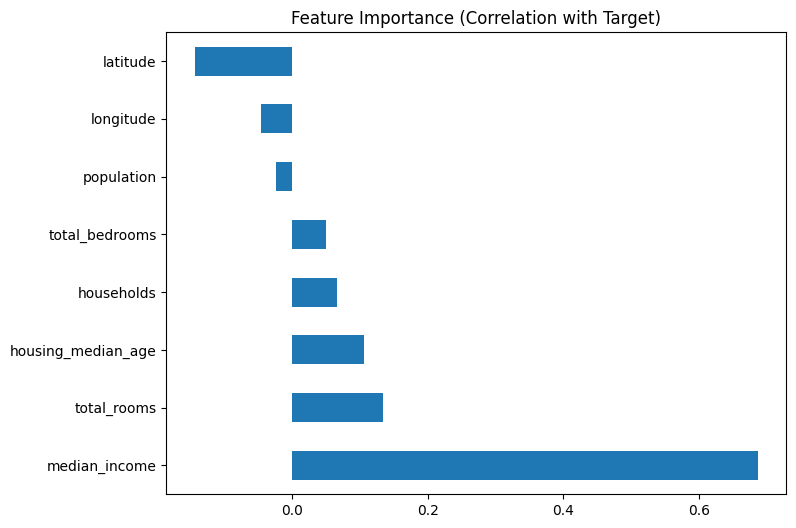

In [ ]:
import matplotlib.pyplot as plt

corr_with_target.drop('median_house_value').plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Correlation with Target)")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 12)
y shape: (20640,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 12)
X_test shape: (4128, 12)
y_train shape: (16512,)
y_test shape: (4128,)


In [ ]:
X_train.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODELS TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lr = lr.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 50670.7382409719
MSE: 4908476721.156616
RMSE: 70060.52184473518
R2 Score: 0.6254240620553606


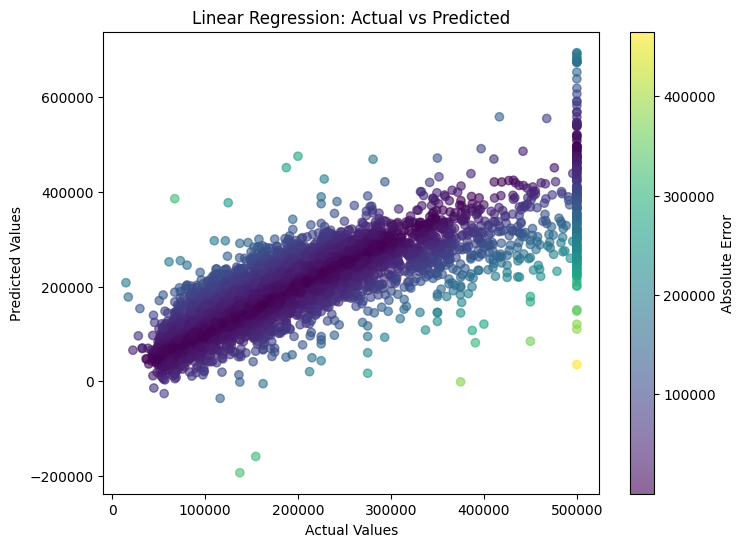

In [ ]:
y_pred = lr.predict(X_test_scaled)

errors = abs(y_test - y_pred)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, c=errors, cmap='viridis', alpha=0.6)

plt.colorbar(label="Absolute Error")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

DT

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))

MAE: 44180.854408914725
MSE: 4865868836.95906
RMSE: 69755.779953772
R2 Score: 0.6286755571919975


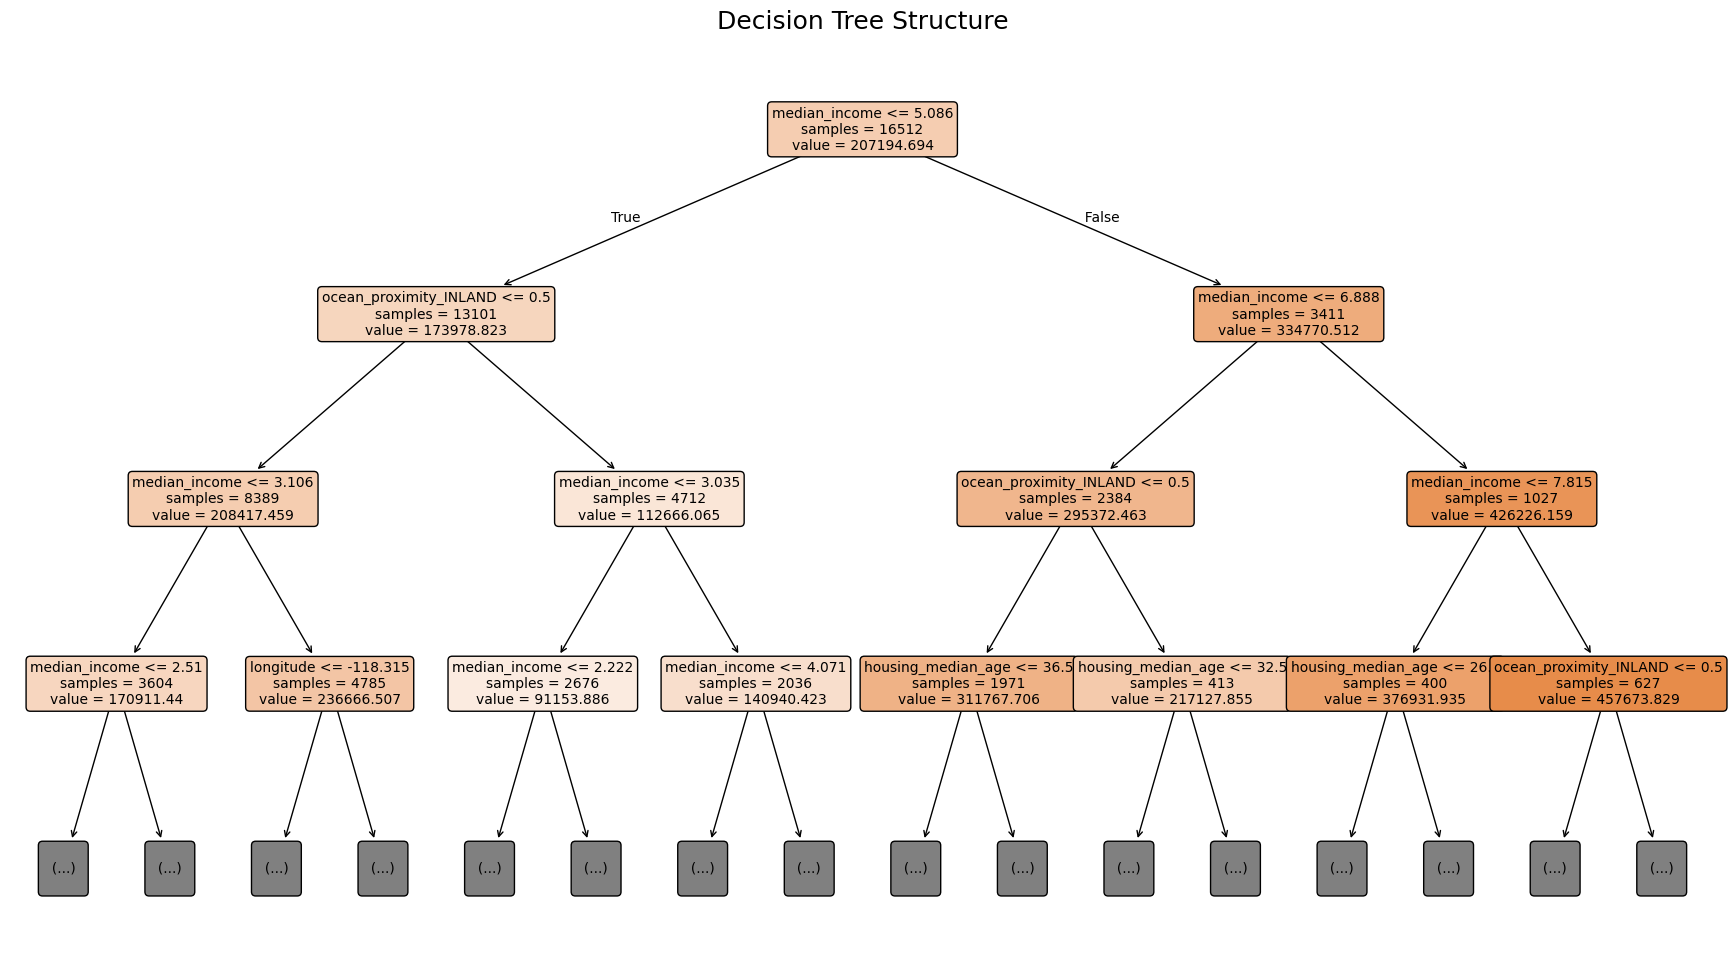

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22,12))

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,
    impurity=False
)

plt.title("Decision Tree Structure", fontsize=18)
plt.show()

random

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 31639.373406007748
MSE: 2404745975.124733
RMSE: 49038.20933848149
R2 Score: 0.8164888965922015


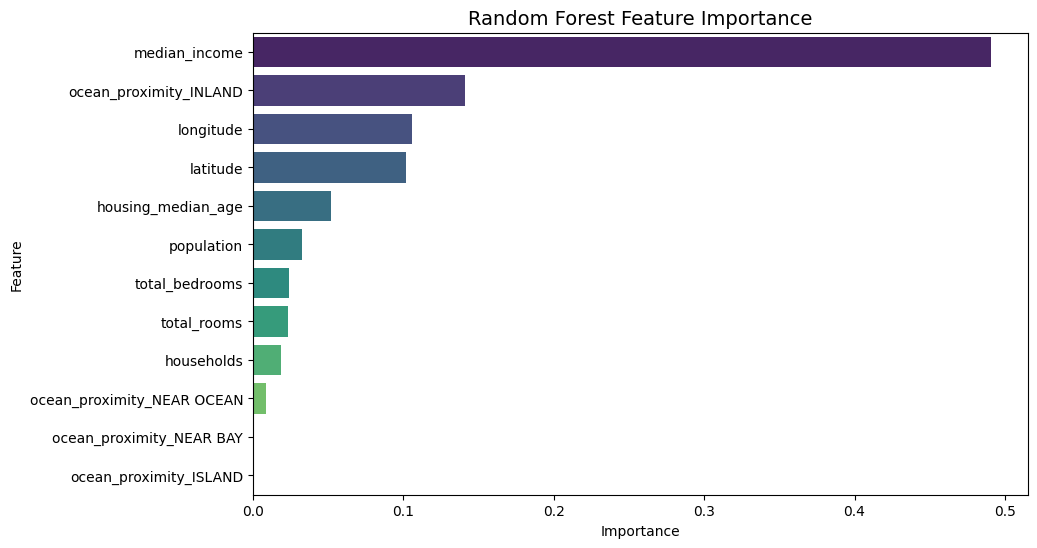

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Random Forest Feature Importance", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

gradient

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("MSE:", mean_squared_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2 Score:", r2_score(y_test, y_pred_gbr))

MAE: 38248.031950045464
MSE: 3123095111.877028
RMSE: 55884.65900295919
R2 Score: 0.7616701988665029


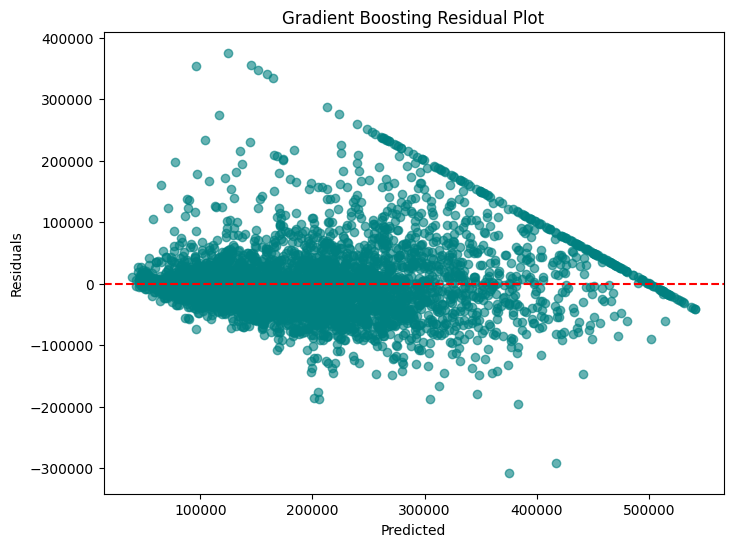

In [ ]:
y_pred = gbr.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6, color='teal')

plt.axhline(y=0, linestyle='--', color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Gradient Boosting Residual Plot")

plt.show()

XG

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 31645.72550361101
MSE: 2238153643.4494147
RMSE: 47309.12854248549
R2 Score: 0.8292018995127823


/tmp/ipykernel_2553/621339330.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


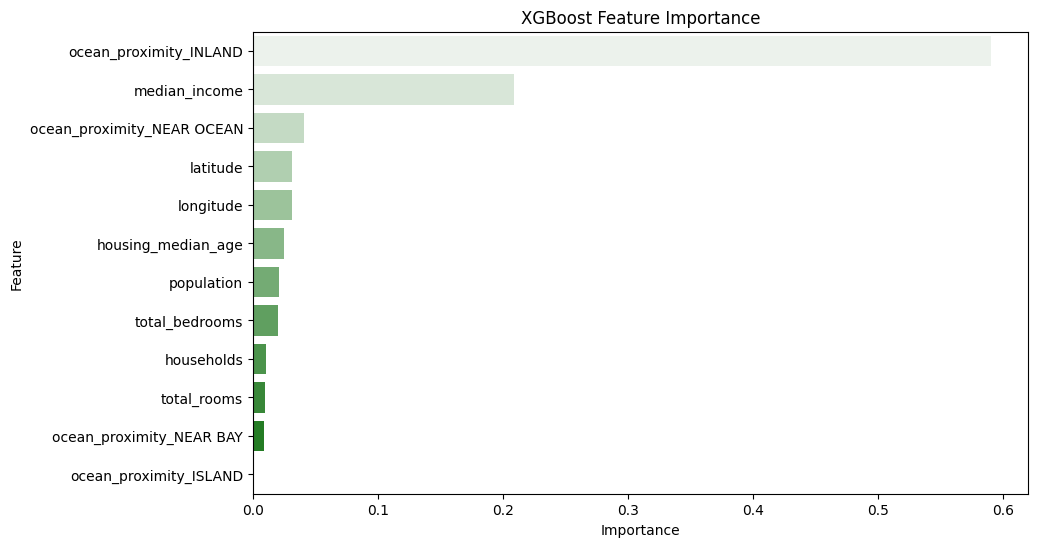

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

colors = sns.light_palette("green", len(importance))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette=colors
)

plt.title("XGBoost Feature Importance")
plt.show()

SVR

In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("R2 Score:", r2_score(y_test, y_pred_svr))

MAE: 86961.49784528147
MSE: 13655973504.4516
RMSE: 116858.77589831069
R2 Score: -0.042115380099383426


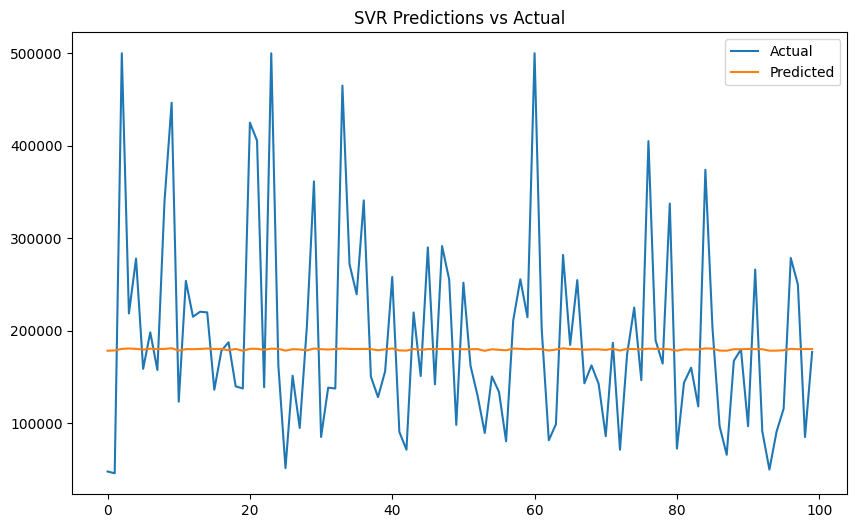

In [ ]:
y_pred = svr.predict(X_test_scaled)

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.legend()

plt.title("SVR Predictions vs Actual")

plt.show()

KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2 Score:", r2_score(y_test, y_pred_knn))

MAE: 40854.39777131783
MSE: 3765913279.631143
RMSE: 61367.037403081005
R2 Score: 0.7126154244847647


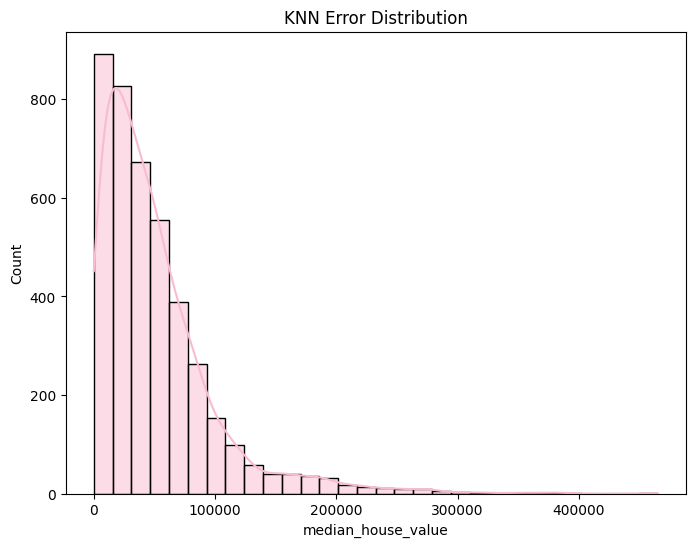

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    errors,
    bins=30,
    kde=True,
    color='#F8BBD0'
)

plt.title("KNN Error Distribution")

plt.show()

RESULTS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# Linear Regression
y_pred = lr.predict(X_test_scaled)
results.append([
    "Linear Regression",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# Decision Tree
y_pred = dt.predict(X_test)
results.append([
    "Decision Tree",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# Random Forest
y_pred = rf.predict(X_test)
results.append([
    "Random Forest",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# Gradient Boosting
y_pred = gbr.predict(X_test)
results.append([
    "Gradient Boosting",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# XGBoost
y_pred = xgb.predict(X_test)
results.append([
    "XGBoost",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# SVR
y_pred = svr.predict(X_test_scaled)
results.append([
    "SVR",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# KNN
y_pred = knn.predict(X_test_scaled)
results.append([
    "KNN",
    mean_absolute_error(y_test, y_pred),
    mean_squared_error(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    r2_score(y_test, y_pred)
])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

# Sort by R² Score (Best Model First)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Model,MAE,MSE,RMSE,R2 Score
4,XGBoost,31645.725504,2.238154e+09,47309.128542,0.829202
2,Random Forest,31639.373406,2.404746e+09,49038.209338,0.816489
3,Gradient Boosting,38248.031950,3.123095e+09,55884.659003,0.761670
6,KNN,40854.397771,3.765913e+09,61367.037403,0.712615
1,Decision Tree,44180.854409,4.865869e+09,69755.779954,0.628676
0,Linear Regression,50670.738241,4.908477e+09,70060.521845,0.625424
5,SVR,86961.497845,1.365597e+10,116858.775898,-0.042115


HYPER PARAMETERS TURNING FOR (XG, RANDOM , GRADIENT AND LINEAR)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.8136528427516426


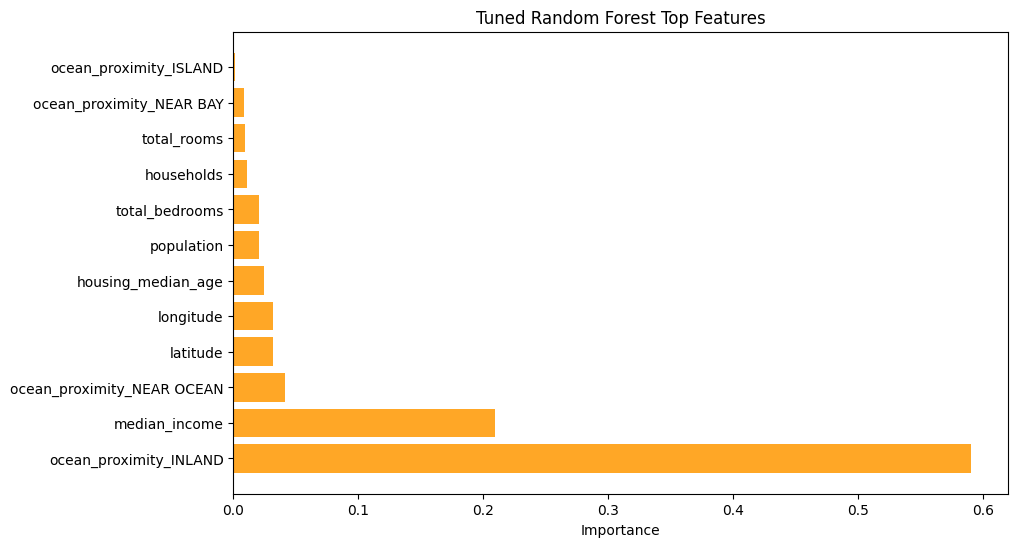

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance'],
    color='#FFA726'
)

plt.title("Tuned Random Forest Top Features")
plt.xlabel("Importance")

plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Score:", gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.8240545099285006


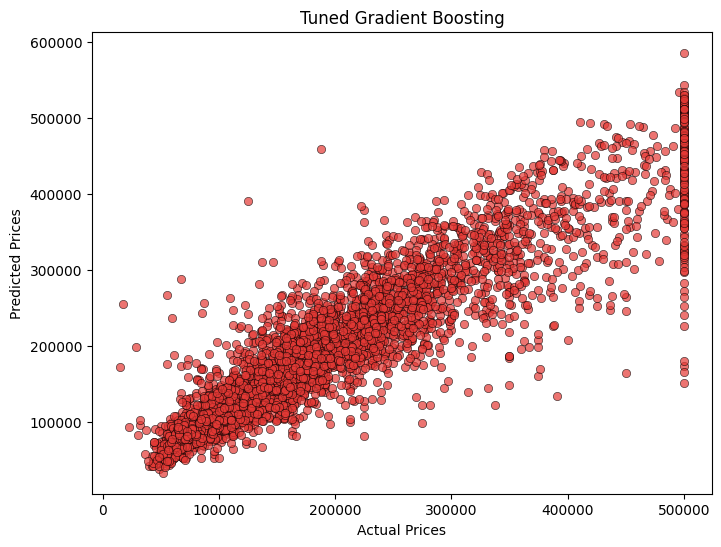

In [ ]:
best_gb = gb_grid.best_estimator_

y_pred = best_gb.predict(X_test)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color='#E53935',
    alpha=0.7,
    edgecolor='black'
)

plt.title("Tuned Gradient Boosting")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb_params = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.8338536191074316


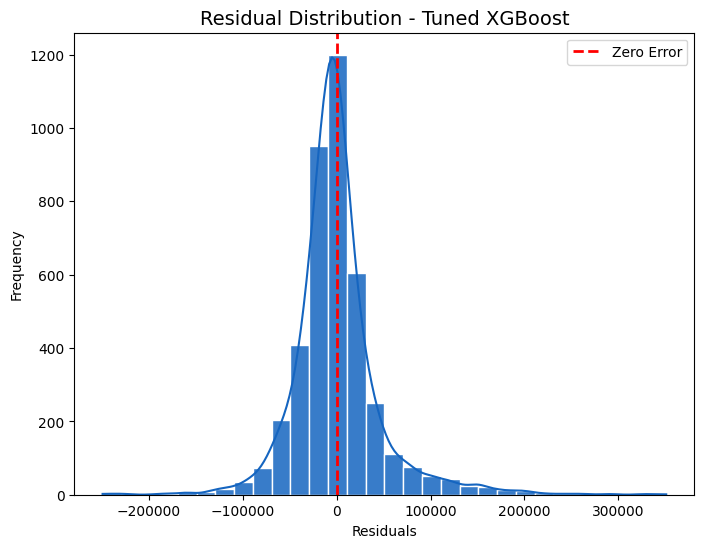

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color='#1565C0',
    edgecolor='white',
    alpha=0.85
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.title("Residual Distribution - Tuned XGBoost", fontsize=14)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.legend()

plt.show()

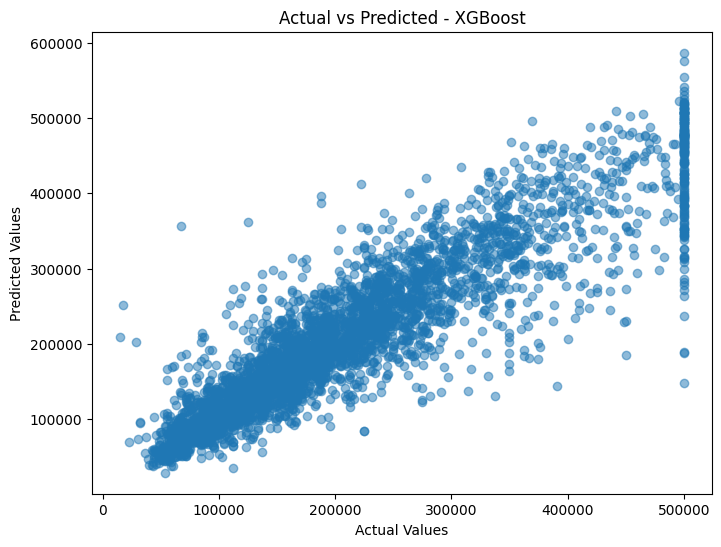

In [ ]:
import matplotlib.pyplot as plt

y_pred = xgb.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - XGBoost")

plt.show()

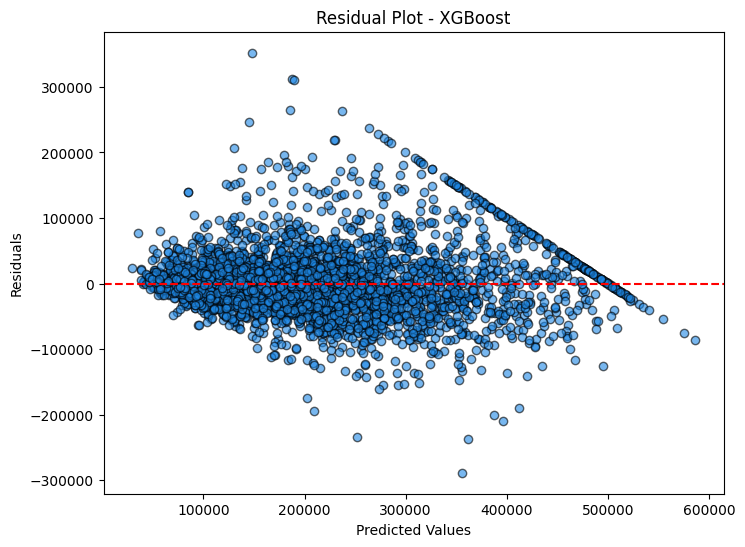

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color='#1E88E5',   # blue
    edgecolor='black'
)

plt.axhline(y=0, linestyle='--', color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost")

plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=3,
    scoring='r2'
)

ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_

print("Best Alpha:", ridge_grid.best_params_)
print("Best CV Score:", ridge_grid.best_score_)

Best Alpha: {'alpha': 10}
Best CV Score: 0.6478768214657091


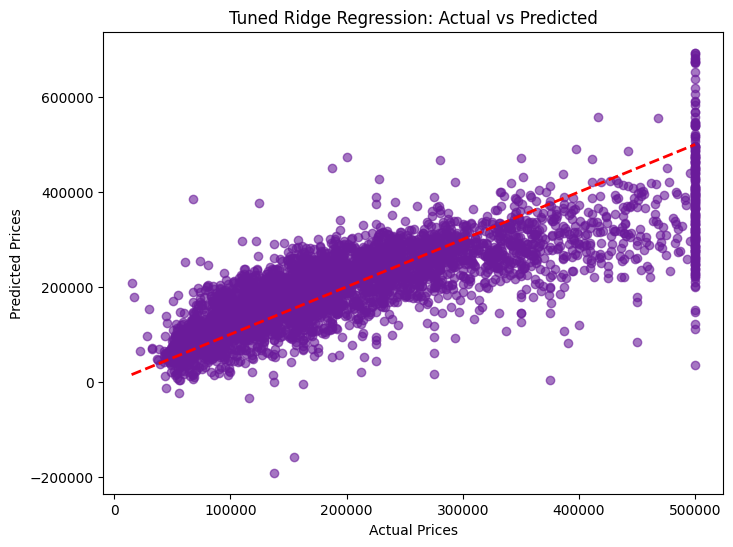

In [ ]:
y_pred = best_ridge.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color="#6A1B9A",
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Tuned Ridge Regression: Actual vs Predicted")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metrics(model, X, y):
    pred = model.predict(X)
    return {
        "MAE": mean_absolute_error(y, pred),
        "MSE": mean_squared_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2 Score": r2_score(y, pred)
    }

before_models = {
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Ridge Regression": Ridge()
}

before_scores = []
for name, model in before_models.items():
    if name == "Ridge Regression":
        model.fit(X_train_scaled, y_train)
        metrics = get_metrics(model, X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        metrics = get_metrics(model, X_test, y_test)

    metrics["Model"] = name
    before_scores.append(metrics)

before_df = pd.DataFrame(before_scores)


best_models = {
    "XGBoost": xgb_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Ridge Regression": ridge_grid.best_estimator_
}

after_scores = []
for name, model in best_models.items():
    if name == "Ridge Regression":
        metrics = get_metrics(model, X_test_scaled, y_test)
    else:
        metrics = get_metrics(model, X_test, y_test)

    metrics["Model"] = name
    after_scores.append(metrics)

after_df = pd.DataFrame(after_scores)


comparison_df = before_df.merge(after_df, on="Model", suffixes=(" (Before)", " (After)"))

comparison_df["MAE % Change"] = ((comparison_df["MAE (Before)"] - comparison_df["MAE (After)"]) / comparison_df["MAE (Before)"]) * 100
comparison_df["RMSE % Change"] = ((comparison_df["RMSE (Before)"] - comparison_df["RMSE (After)"]) / comparison_df["RMSE (Before)"]) * 100
comparison_df["R2 % Change"] = ((comparison_df["R2 Score (After)"] - comparison_df["R2 Score (Before)"]) / comparison_df["R2 Score (Before)"]) * 100

comparison_df

,MAE (Before),MSE (Before),RMSE (Before),R2 Score (Before),Model,MAE (After),MSE (After),RMSE (After),R2 Score (After),MAE % Change,RMSE % Change,R2 % Change
0,31645.725504,2.238154e+09,47309.128542,0.829202,XGBoost,30087.044708,2.156202e+09,46434.919525,0.835456,4.925407,1.847865,0.754209
1,31639.373406,2.404746e+09,49038.209338,0.816489,Random Forest,31492.938259,2.386213e+09,48848.879242,0.817903,0.462826,0.386087,0.173216
2,38248.031950,3.123095e+09,55884.659003,0.761670,Gradient Boosting,32057.322286,2.297175e+09,47928.851646,0.824698,16.185695,14.236120,8.274930
3,50668.122931,4.908042e+09,70057.416870,0.625457,Ridge Regression,50646.170659,4.904384e+09,70031.305311,0.625736,0.043326,0.037272,0.044630


/tmp/ipykernel_2553/3224585227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


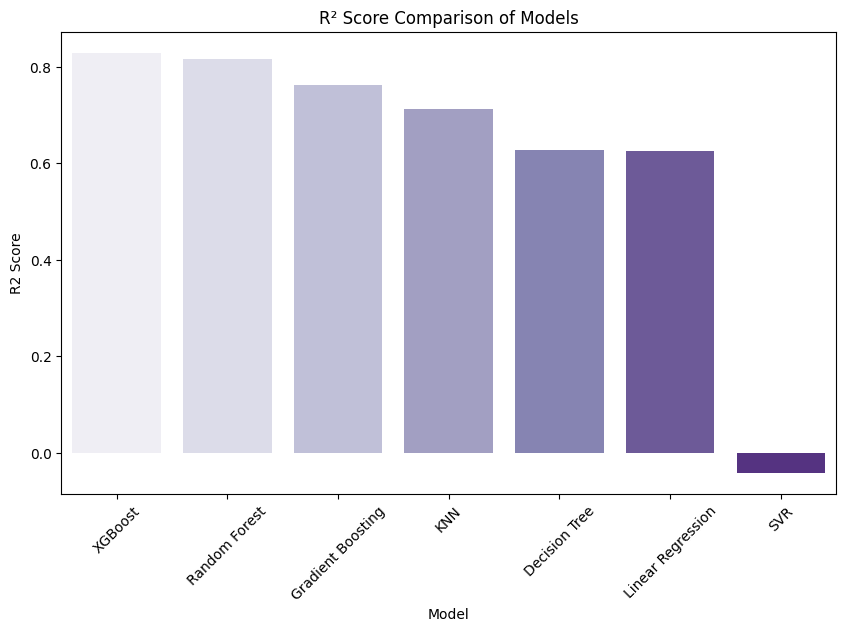

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df,
    palette='Purples'
)

plt.xticks(rotation=45)
plt.title("R² Score Comparison of Models")

plt.show()

/tmp/ipykernel_2553/10759064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


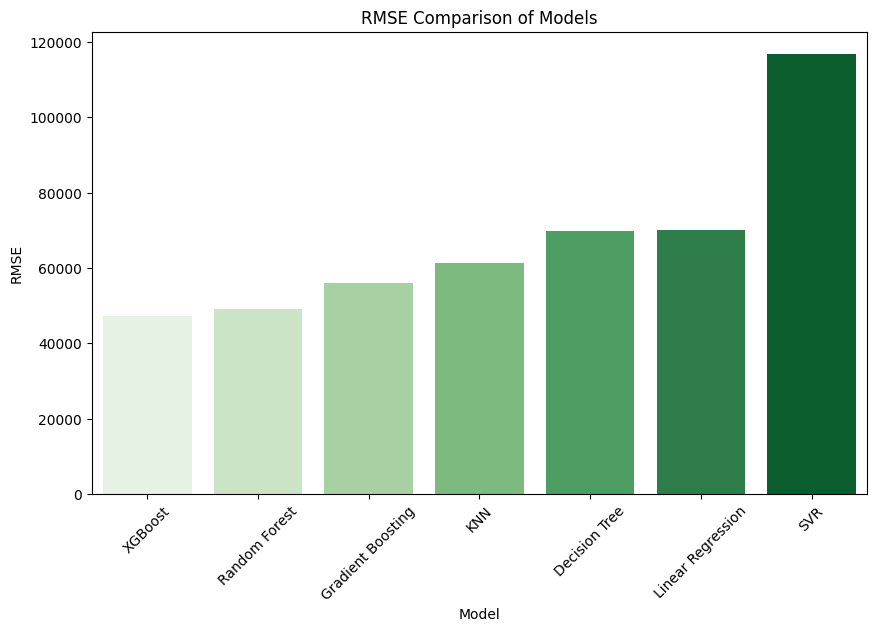

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='RMSE',
    data=results_df,
    palette='Greens'
)

plt.xticks(rotation=45)
plt.title("RMSE Comparison of Models")

plt.show()

best model selection

In [ ]:
best_model_row = after_df.sort_values(by="R2 Score", ascending=False).iloc[0]

print("Best Model Selected:")
print(best_model_row)

Best Model Selected:
MAE              30087.044708
MSE         2156201751.288924
RMSE             46434.919525
R2 Score             0.835456
Model                 XGBoost
Name: 0, dtype: object


Predictions

In [ ]:
y_pred = xgb_grid.best_estimator_.predict(X_test)

In [ ]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison_df.head(15)

,Actual Price,Predicted Price
0,47700.0,53648.921875
1,45800.0,72783.460938
2,500001.0,474902.031250
3,218600.0,245135.546875
4,278000.0,273031.281250
5,158700.0,171483.875000
6,198200.0,274506.312500
7,157500.0,182561.156250
8,340000.0,280489.812500
9,446600.0,466959.562500


In [ ]:
sample = X_test.iloc[0].values.reshape(1, -1)

predicted_price = final_model.predict(sample)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 53648.92


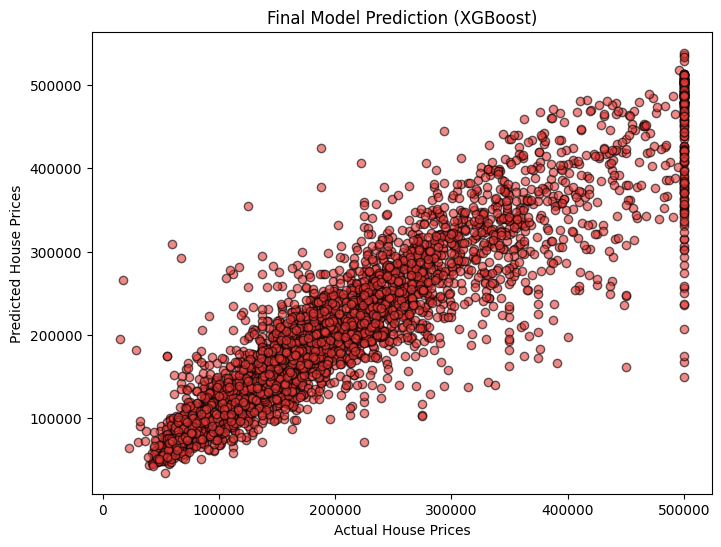

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6, color='#E53935', edgecolor='black')

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Final Model Prediction (XGBoost)")

plt.show()

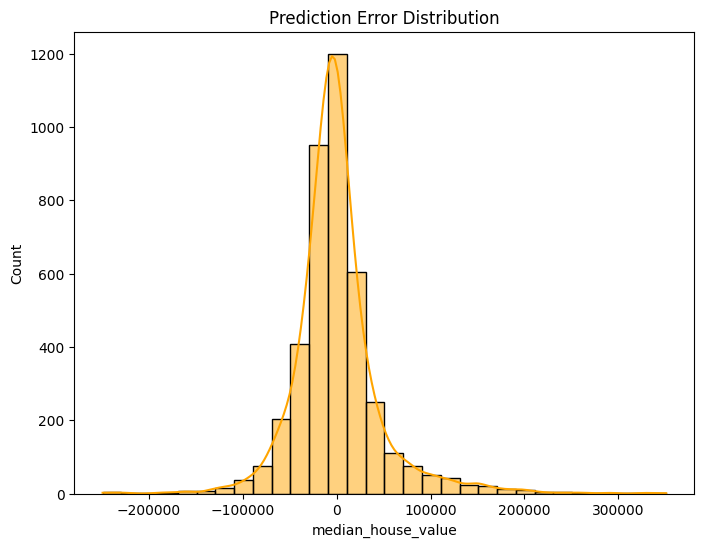

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(errors, bins=30, kde=True, color='orange')

plt.title("Prediction Error Distribution")

plt.show()

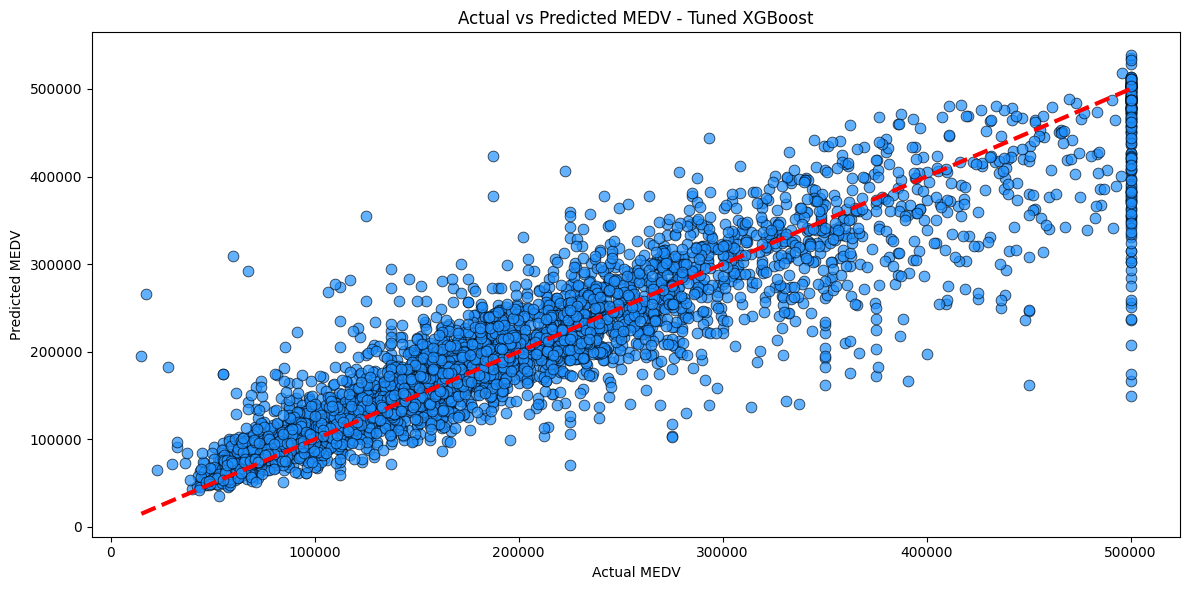

In [ ]:
y_pred = xgb_grid.best_estimator_.predict(X_test)

plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test, y=y_pred, color='dodgerblue', s=60, alpha=0.7, edgecolor='k')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=3)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted MEDV - Tuned XGBoost")

plt.tight_layout()
plt.show()

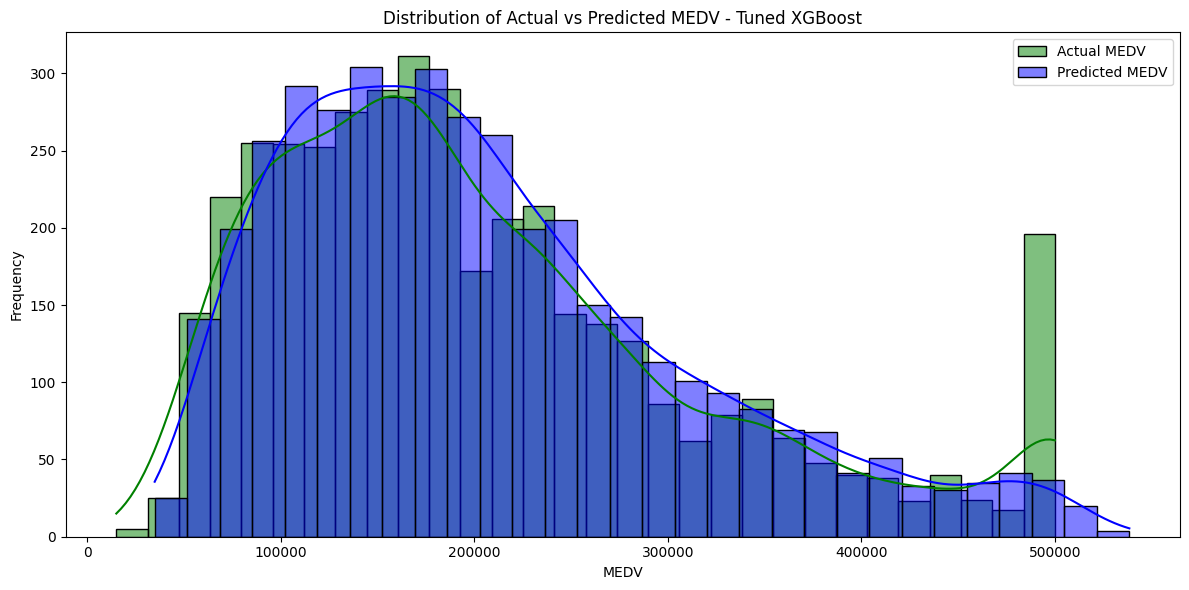

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(y_test, color='green', label='Actual MEDV', kde=True, bins=30, alpha=0.5)
sns.histplot(y_pred, color='blue', label='Predicted MEDV', kde=True, bins=30, alpha=0.5)

plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.title("Distribution of Actual vs Predicted MEDV - Tuned XGBoost")

plt.legend()
plt.tight_layout()
plt.show()

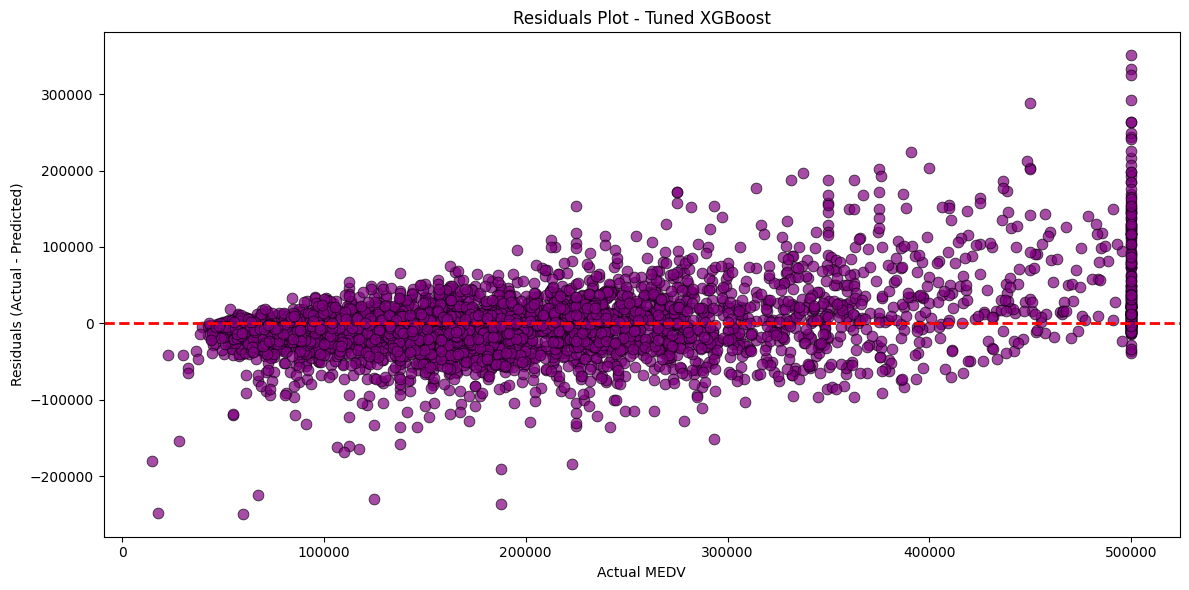

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test, y=residuals, color='purple', s=60, alpha=0.7, edgecolor='k')

plt.axhline(0, color='red', linestyle='--', lw=2)

plt.xlabel("Actual MEDV")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - Tuned XGBoost")

plt.tight_layout()
plt.show()

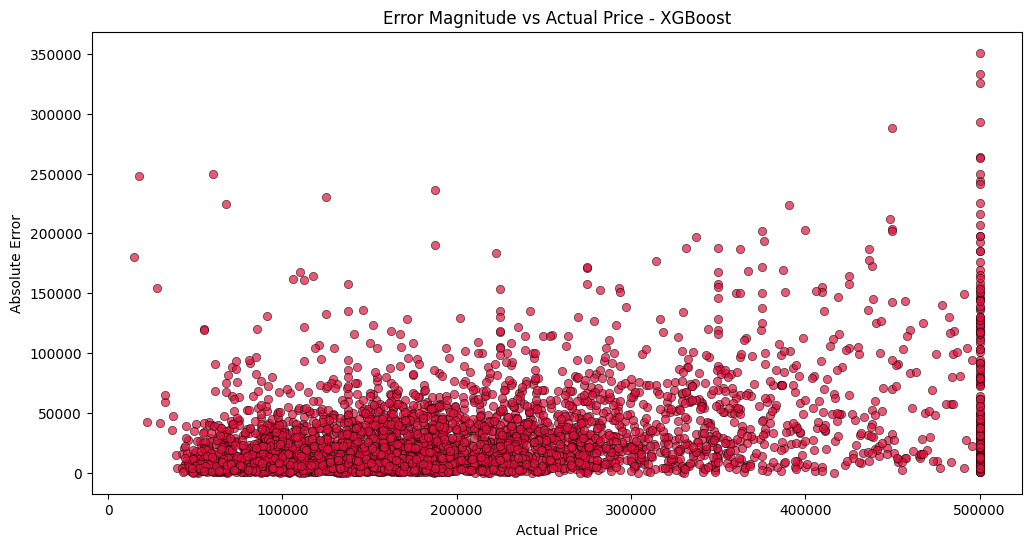

In [ ]:
errors = abs(y_test - y_pred)

plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test, y=errors, color='crimson', edgecolor='black', alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Absolute Error")
plt.title("Error Magnitude vs Actual Price - XGBoost")

plt.show()

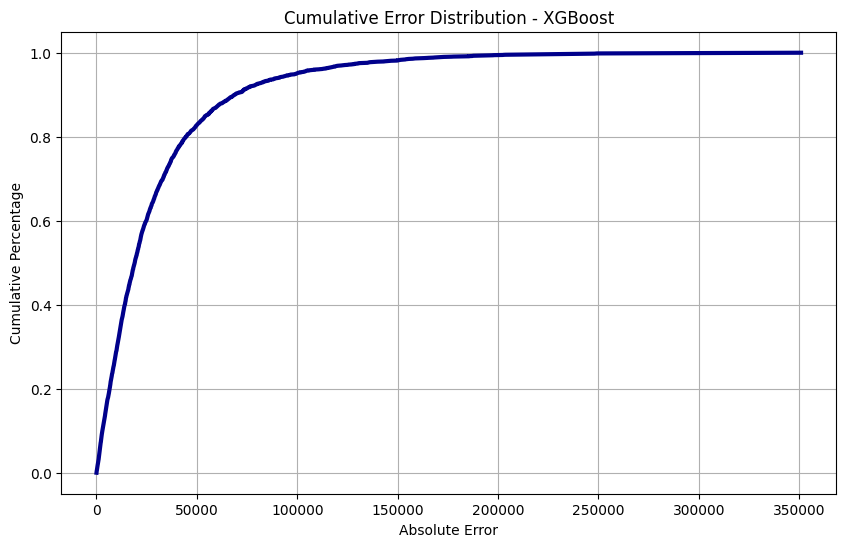

In [ ]:
sorted_errors = np.sort(abs(y_test - y_pred))
y_vals = np.arange(len(sorted_errors)) / len(sorted_errors)

plt.figure(figsize=(10,6))
plt.plot(sorted_errors, y_vals, color='darkblue', linewidth=3)

plt.xlabel("Absolute Error")
plt.ylabel("Cumulative Percentage")
plt.title("Cumulative Error Distribution - XGBoost")

plt.grid()
plt.show()

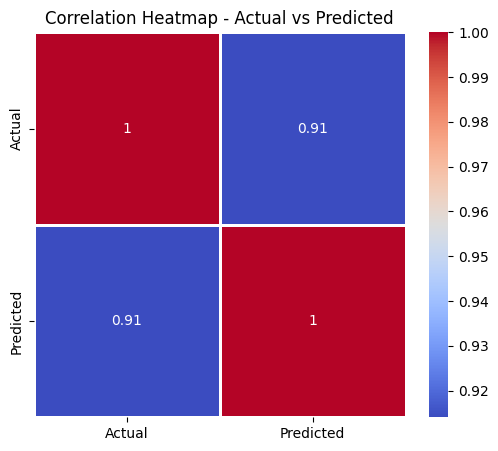

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

corr = df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=1)

plt.title("Correlation Heatmap - Actual vs Predicted")
plt.show()

/tmp/ipykernel_2553/2070274056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=worst["Error"], y=worst.index, palette="Reds_r")


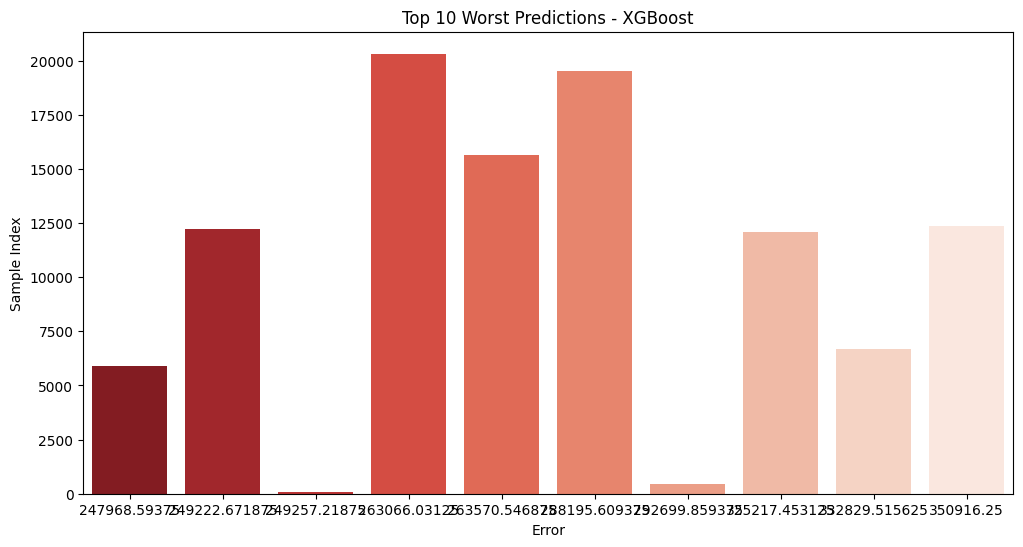

In [ ]:
df["Error"] = abs(df["Actual"] - df["Predicted"])
worst = df.sort_values("Error", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=worst["Error"], y=worst.index, palette="Reds_r")

plt.title("Top 10 Worst Predictions - XGBoost")
plt.xlabel("Error")
plt.ylabel("Sample Index")

plt.show()

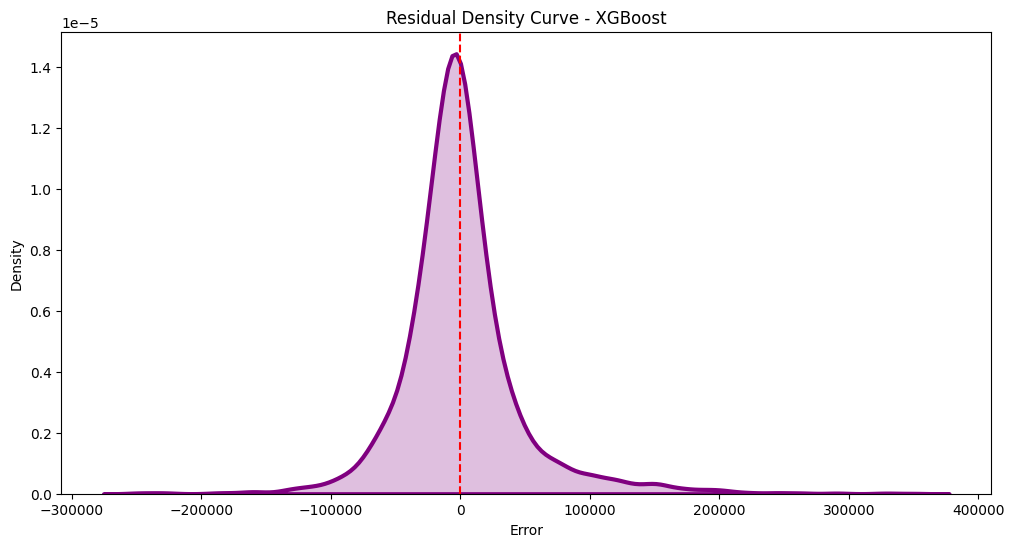

In [ ]:
plt.figure(figsize=(12,6))
sns.kdeplot(y_test - y_pred, fill=True, color="purple", linewidth=3)

plt.axvline(0, color='red', linestyle='--')

plt.title("Residual Density Curve - XGBoost")
plt.xlabel("Error")

plt.show()

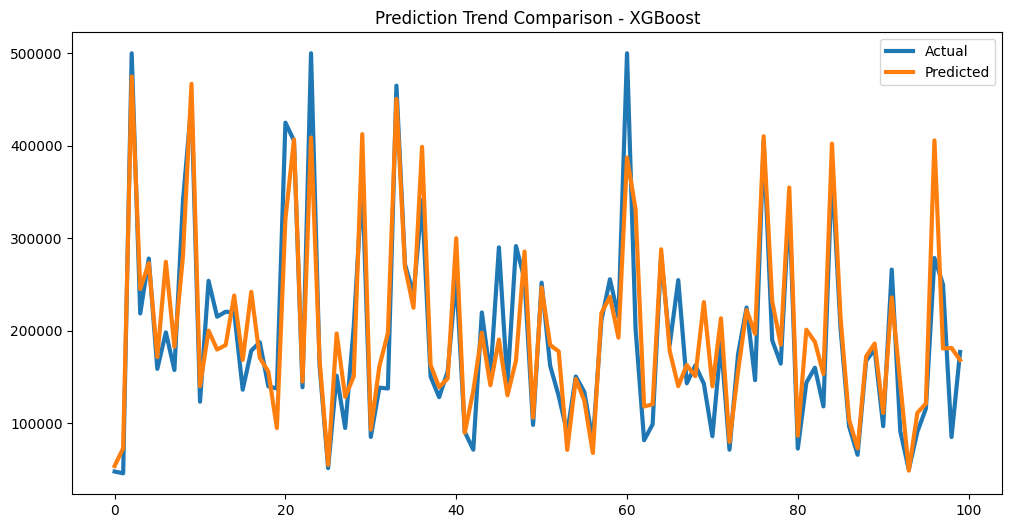

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual", linewidth=3)
plt.plot(y_pred[:100], label="Predicted", linewidth=3)

plt.legend()
plt.title("Prediction Trend Comparison - XGBoost")

plt.show()

DEPLOYMENT WORKING

In [ ]:
!pip install streamlit

In [ ]:
print(X.columns.tolist())

In [ ]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved successfully")

In [ ]:
import pickle

defaults = {
    "longitude": df["longitude"].mean(),
    "latitude": df["latitude"].mean(),
    "housing_median_age": df["housing_median_age"].mean(),
    "households": df["households"].mean()
}

with open("defaults.pkl", "wb") as f:
    pickle.dump(defaults, f)

print("Defaults saved successfully")

In [ ]:
from google.colab import files

files.download("best_model.pkl")
files.download("defaults.pkl")

In [ ]:
import streamlit as st
import pandas as pd
import pickle

# -----------------------------
# Load Model
# -----------------------------

with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("defaults.pkl", "rb") as f:
    defaults = pickle.load(f)

# -----------------------------
# Page Settings
# -----------------------------

st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠"
)

st.title("🏠 California House Price Prediction")
st.write("Enter the property details below.")

# -----------------------------
# User Inputs
# -----------------------------

median_income = st.number_input(
    "Median Income",
    min_value=0.0,
    value=5.0
)

total_rooms = st.number_input(
    "Total Rooms",
    min_value=1,
    value=2000
)

total_bedrooms = st.number_input(
    "Total Bedrooms",
    min_value=1,
    value=400
)

population = st.number_input(
    "Population",
    min_value=0,
    value=1000
)

location = st.selectbox(
    "Location",
    [
        "<1H OCEAN",
        "INLAND",
        "ISLAND",
        "NEAR BAY",
        "NEAR OCEAN"
    ]
)

# -----------------------------
# Prediction
# -----------------------------

if st.button("Predict House Price"):

    inland = 0
    island = 0
    near_bay = 0
    near_ocean = 0

    if location == "INLAND":
        inland = 1
    elif location == "ISLAND":
        island = 1
    elif location == "NEAR BAY":
        near_bay = 1
    elif location == "NEAR OCEAN":
        near_ocean = 1

    input_df = pd.DataFrame([{
        "longitude": defaults["longitude"],
        "latitude": defaults["latitude"],
        "housing_median_age": defaults["housing_median_age"],
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": defaults["households"],
        "median_income": median_income,
        "ocean_proximity_INLAND": inland,
        "ocean_proximity_ISLAND": island,
        "ocean_proximity_NEAR BAY": near_bay,
        "ocean_proximity_NEAR OCEAN": near_ocean
    }])

    prediction = model.predict(input_df)

    st.success(f"Predicted House Price: ${prediction[0]:,.2f}")

In [ ]:
from google.colab import files

files.download("app.py")